# Bull vs Bear Debate

**Docker image**: `ml4t`

This notebook implements **structured adversarial debate**, the mechanism that
stress-tests the agent ensemble by forcing explicit bull and bear arguments.
The key output is not which side "wins" but whether the bull-bear gap narrows
under adversarial pressure.

The `DebateAgent` class built here can make live LLM calls. The default path
replays a pinned transcript, so each side's response remains inspectable
without spending money or changing the result.

**Learning Objectives**:
- Build a multi-round debate with real LLM calls and structured prompts
- Detect consensus when the bull-bear gap closes below a threshold
- Visualize the bull-bear probability gap across debate rounds
- Understand when debate adds value vs when it's noise

**Book Reference**: Chapter 24, Section 24.7 (Multi-Agent Forecasting Systems —
Debate Pattern)

**Prerequisites**: NB04 (research agent), NB05 (aggregation math), NB06 (multi-agent).

**The question, and why it differs from NB06.** This notebook forecasts the
pinned `CHAPTER_CONTESTED_QUESTION` (*"Will the Federal Reserve hike rates in
2026?"*), which the Polymarket market priced near `p_yes ≈ 0.55` on the
2026-06-09 capture date, with credible evidence on both sides. NB06 used the
pinned `CHAPTER_CLEAR_QUESTION` (the recession question) precisely *because* its
evidence points one way, and the agents there agreed closely. Here the evidence
genuinely cuts both ways, so the agents spread out, and that disagreement is
what gives debate something to work on. Same agent class, same temperature: the
only thing that changed is the question. As with NB06, the numbers come from one
live `claude-sonnet-4` run, a dated point-in-time capture rather than a
reproducible seed. By default this notebook *replays* that pinned 2026-06-09 run
(`RUN_LIVE = False`): it reloads the saved agent panel and debate transcript and
makes no API calls, so the table, transcript, and trajectory figure are stable.
Set `RUN_LIVE = True` (with `ANTHROPIC_API_KEY` and `TAVILY_API_KEY`) to debate
a current question live, which is not reproducible.

In [1]:
"""Bull vs Bear Debate — adversarial stress-testing of forecasts."""

import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import polars as pl
from agent_fixtures import get_chapter_contested_question
from agent_observability import (
    TRACES_DIR,
    RunTrace,
    merge_calls,
    replay_llm_calls,
    show_agents,
    show_debate_transcript,
    trace_llm,
)
from agent_pipeline import neyman_extremize
from agent_providers import ChatMessage, TokenUsage, create_llm_client
from agent_research import ResearchAgent, format_agent_summary, parse_json
from agent_schemas import AgentForecastArtifact, DebateArtifact, DebateRound
from agent_tools import create_search_client

from utils.style import COLORS, add_message_title

In [2]:
# RUN_LIVE=False (the default) replays the pinned 2026-06-09 trace named below:
# the notebook reloads that saved run and makes no API calls. Set RUN_LIVE=True
# (with API keys) to debate a current question live; that path produces different
# numbers.
RUN_LIVE = False
PINNED_TRACE = "07_adversarial_debate_20260609T141631Z_cf1ad76cf379.json"

# Empty string auto-detects a provider (see NB06's note); the captured run used
# claude-sonnet-4. LLM_PROVIDER="mock" is a CI smoke-test only (live path).
LLM_PROVIDER = ""
N_AGENTS = 3
DEBATE_ROUNDS = 3
CONSENSUS_THRESHOLD = 0.05
MAX_STEPS = 5

## Debate Prompts: Bull

The bull argues for a higher probability of YES. In round 1, `{bear_section}`
is empty and the bull argues without seeing the bear's position. In
subsequent rounds, the placeholder carries the bear's previous argument
and the bull must directly address it.

In [3]:
BULL_PROMPT_TEMPLATE = """\
You are the BULL debater in a structured forecasting debate.

Your role is to argue for a HIGHER probability of YES for the question below.
You must present the strongest possible case for YES, backed by evidence.

QUESTION:
{question}

AGENT SUMMARIES:
{agent_summaries}

CURRENT AGGREGATE PROBABILITY: {aggregate_p_yes}

{bear_section}

Output JSON only:
{{"argument": "Your strongest case for a higher probability of YES", "p_yes": 0.XX, "key_evidence": ["evidence point 1", "evidence point 2", "evidence point 3"]}}"""

## Debate Prompts: Bear

The bear argues for a lower probability of YES. The bull's argument and
probability are inserted into the template every round, so the bear is
always responding to the most recent bull position.

In [4]:
BEAR_PROMPT_TEMPLATE = """\
You are the BEAR debater in a structured forecasting debate.

Your role is to argue for a LOWER probability of YES for the question below.
You must present the strongest possible case for NO (or lower probability), backed by evidence.

QUESTION:
{question}

AGENT SUMMARIES:
{agent_summaries}

CURRENT AGGREGATE PROBABILITY: {aggregate_p_yes}

BULL'S ARGUMENT:
{bull_argument}
Bull's probability: {bull_probability}

You must directly address the Bull's points and explain why the probability should be lower.

Output JSON only:
{{"argument": "Your strongest case for a lower probability of YES", "p_yes": 0.XX, "key_evidence": ["evidence point 1", "evidence point 2", "evidence point 3"]}}"""

## One bull turn

The bull sees the common evidence and, after round one, the bear's previous
position. This helper returns the parsed argument, probability, evidence,
and token count.

In [5]:
def _run_bull_turn(
    llm,
    question: str,
    agent_summaries: str,
    aggregate_p_yes: float,
    prev_bear_argument: str | None,
    prev_bear_probability: float | None,
) -> tuple[str, float, list[str], TokenUsage]:
    """Run and parse one bull turn."""
    bear_section = ""
    if prev_bear_argument is not None:
        bear_section = (
            f"BEAR'S PREVIOUS ARGUMENT:\n{prev_bear_argument}\n"
            f"Bear's probability: {prev_bear_probability:.4f}\n\n"
            "You must directly address the Bear's points and explain "
            "why the probability should be higher."
        )

    bull_prompt = BULL_PROMPT_TEMPLATE.format(
        question=question,
        agent_summaries=agent_summaries,
        aggregate_p_yes=f"{aggregate_p_yes:.4f}",
        bear_section=bear_section,
    )
    bull_raw, bull_tokens = llm.complete_with_usage(
        [ChatMessage(role="user", content=bull_prompt)], json_mode=True
    )
    bull_parsed = parse_json(bull_raw)
    return (
        bull_parsed.get("argument", ""),
        float(bull_parsed.get("p_yes", aggregate_p_yes)),
        [str(e) for e in bull_parsed.get("key_evidence", [])],
        bull_tokens,
    )

## One bear turn

The bear always receives the current bull argument. Keeping the two model
calls separate makes the evidence flow and token accounting explicit.

In [6]:
def _run_bear_turn(
    llm,
    question: str,
    agent_summaries: str,
    aggregate_p_yes: float,
    bull_argument: str,
    bull_probability: float,
) -> tuple[str, float, list[str], TokenUsage]:
    """Run and parse one bear turn."""

    bear_prompt = BEAR_PROMPT_TEMPLATE.format(
        question=question,
        agent_summaries=agent_summaries,
        aggregate_p_yes=f"{aggregate_p_yes:.4f}",
        bull_argument=bull_argument,
        bull_probability=f"{bull_probability:.4f}",
    )
    bear_raw, bear_tokens = llm.complete_with_usage(
        [ChatMessage(role="user", content=bear_prompt)], json_mode=True
    )
    bear_parsed = parse_json(bear_raw)
    return (
        bear_parsed.get("argument", ""),
        float(bear_parsed.get("p_yes", aggregate_p_yes)),
        [str(e) for e in bear_parsed.get("key_evidence", [])],
        bear_tokens,
    )

## Single-round driver

One round runs bull then bear and checks whether their probabilities fall
within the declared consensus threshold.

In [7]:
def _run_debate_round(
    llm,
    round_num: int,
    question: str,
    agent_summaries: str,
    aggregate_p_yes: float,
    previous_bear: tuple[str, float] | None,
    consensus_threshold: float,
) -> tuple[DebateRound, TokenUsage]:
    """Run one bull-to-bear round."""
    prev_argument, prev_probability = previous_bear or (None, None)
    bull_argument, bull_p, bull_evidence, bull_tokens = _run_bull_turn(
        llm,
        question,
        agent_summaries,
        aggregate_p_yes,
        prev_argument,
        prev_probability,
    )
    bear_argument, bear_p, bear_evidence, bear_tokens = _run_bear_turn(
        llm, question, agent_summaries, aggregate_p_yes, bull_argument, bull_p
    )

    debate_round = DebateRound(
        round_number=round_num,
        bull_argument=bull_argument,
        bull_probability=bull_p,
        bear_argument=bear_argument,
        bear_probability=bear_p,
        consensus_reached=abs(bull_p - bear_p) < consensus_threshold,
        bull_key_evidence=bull_evidence,
        bear_key_evidence=bear_evidence,
    )
    return debate_round, bull_tokens + bear_tokens

## Multi-round driver

The driver carries the latest bear position into the next bull prompt and
stops once the declared consensus rule fires.

In [8]:
def _conduct_debate(
    llm,
    question: str,
    agent_summaries: str,
    aggregate_p_yes: float,
    max_rounds: int,
    consensus_threshold: float,
) -> tuple[DebateArtifact, TokenUsage]:
    rounds: list[DebateRound] = []
    tokens = TokenUsage()
    previous_bear: tuple[str, float] | None = None
    for round_num in range(1, max_rounds + 1):
        round_result, round_tokens = _run_debate_round(
            llm,
            round_num,
            question,
            agent_summaries,
            aggregate_p_yes,
            previous_bear,
            consensus_threshold,
        )
        rounds.append(round_result)
        tokens = tokens + round_tokens
        if round_result.consensus_reached:
            break
        previous_bear = (round_result.bear_argument, round_result.bear_probability)
    last = rounds[-1]
    return (
        DebateArtifact(
            rounds=rounds,
            bull_final_probability=last.bull_probability,
            bear_final_probability=last.bear_probability,
            consensus_reached=last.consensus_reached,
            early_termination=last.consensus_reached and len(rounds) < max_rounds,
            token_usage=tokens,
        ),
        tokens,
    )

## The DebateAgent Class

Multi-round bull/bear debate. The class owns the LLM, the round budget,
and the consensus threshold; `run()` walks the rounds via the driver
above and assembles a `DebateArtifact` with the full transcript.

In [9]:
class DebateAgent:
    """Structured adversarial debate between bull and bear positions."""

    def __init__(
        self,
        llm,
        max_rounds: int = 3,
        consensus_threshold: float = 0.05,
    ) -> None:
        self.llm = llm
        self.max_rounds = max_rounds
        self.consensus_threshold = consensus_threshold
        self.token_usage = TokenUsage()

    def run(
        self,
        question: str,
        agent_summaries: str,
        aggregate_p_yes: float,
    ) -> DebateArtifact:
        """Run the debate. Returns a DebateArtifact with full transcript."""
        artifact, self.token_usage = _conduct_debate(
            self.llm,
            question,
            agent_summaries,
            aggregate_p_yes,
            self.max_rounds,
            self.consensus_threshold,
        )
        return artifact

## Setup: Run Research Agents

We first run the research agents from NB06 to establish baseline probability
estimates that the debate will stress-test — this time on the pinned contested
question, where the agents are expected to disagree.

In [10]:
artifacts: list[AgentForecastArtifact] = []

if RUN_LIVE:
    llm = create_llm_client(LLM_PROVIDER)
    search = create_search_client(LLM_PROVIDER)
    question = get_chapter_contested_question()
    provider_name = llm.model_name

    # Run N agents, each under its own tracer so the full conversation — every
    # prompt sent and every raw response — is captured and attributed per agent.
    agent_tracers = []
    for i in range(N_AGENTS):
        tracer = trace_llm(llm, label=f"agent_{i}")
        agent = ResearchAgent(llm=tracer, search=search, agent_id=f"agent_{i}", max_steps=MAX_STEPS)
        artifacts.append(agent.run(question, market_price=question.current_market_price))
        agent_tracers.append(tracer)
else:
    # Replay: reload the pinned trace and rehydrate the agent panel and debate.
    pinned_run = RunTrace.load(TRACES_DIR / PINNED_TRACE)
    question = pinned_run.question_obj()
    provider_name = pinned_run.provider
    artifacts = pinned_run.agent_artifacts()

artifacts.sort(key=lambda a: a.agent_id)
probs = [a.p_yes for a in artifacts]
aggregate = neyman_extremize(probs, base=0.5, correlation=0.3)

print(f"Mode:         {'LIVE' if RUN_LIVE else 'REPLAY (pinned 2026-06-09 trace)'}")
print(f"Provider:     {provider_name}")
print(f"Question:     {question.question}")
print(f"Market p_yes: {question.current_market_price}\n")
print("Pre-debate agent estimates:")
for a in artifacts:
    print(f"  {a.agent_id}: p_yes={a.p_yes:.2f}, confidence={a.confidence:.2f}")
print(f"\nAggregate (Neyman ρ=0.3): {aggregate.extremized_probability:.2f}")

Mode:         REPLAY (pinned 2026-06-09 trace)
Provider:     claude-sonnet-4-20250514
Question:     Will the Federal Reserve hike rates in 2026?
Market p_yes: 0.545

Pre-debate agent estimates:
  agent_0: p_yes=0.35, confidence=0.30
  agent_1: p_yes=0.58, confidence=0.16
  agent_2: p_yes=0.38, confidence=0.24

Aggregate (Neyman ρ=0.3): 0.41


### Pre-debate agent timelines

Before the debate stress-tests them, here is the full captured run for each
research agent — every query, the documents retrieved, and the untruncated
rationale — rendered by the same `show_agents` observability helper used in
NB06. On this contested question the agents enter the debate already
disagreeing; the timelines show *which* evidence pulled each one toward its
starting probability.

In [11]:
print(show_agents(artifacts))

  AGENT_0  ·  p_yes=0.35  confidence=0.30  sentiment=bearish  evidence=high
  searches=3  sources=15  tokens=25,139
  Step 1 · SEARCH  "Federal Reserve interest rate projections 2025 2026 economic outlook inflation"
      1. [?] [PDF] The U.S. Economic Outlook for 2025–2026 - University of Michigan
         https://lsa.umich.edu/content/dam/econ-assets/Econdocs/RSQE%20PDFs/RSQE_US_Forecast_Feb25.pdf
         We project PCE inflation to hold steady near a 2.2 percent annualized
         rate from 2025Q4–2026Q4 .Even so, we expect two more 25 basis point
         cuts in 2026, bringing the fed funds rate to 3.25–3.5 percent by the
         end of 2026, the terminal range for this cycle. It is increasingly
         likely…
      2. [?] Federal Reserve Monetary Policy | U.S. Bank
         https://www.usbank.com/investing/financial-perspectives/market-news/federal-reserve-tapering-asset-purchases.html
         [](https://twitter.com/intent/tweet?url=https://www.usbank.com/conten
         t/

## Running the Debate

The `DebateAgent` makes real LLM calls for each round. The bull and bear
prompts include the agent summaries so both sides argue from the same
evidence base.

In [12]:
agg_p = aggregate.extremized_probability or aggregate.raw_probability

if RUN_LIVE:
    agent_summaries = "\n\n---\n\n".join(format_agent_summary(a) for a in artifacts)
    debate_tracer = trace_llm(llm, label="debate")
    debate = DebateAgent(
        llm=debate_tracer,
        max_rounds=DEBATE_ROUNDS,
        consensus_threshold=CONSENSUS_THRESHOLD,
    )
    result = debate.run(
        question=question.question,
        agent_summaries=agent_summaries,
        aggregate_p_yes=agg_p,
    )
    debate_tokens = debate.token_usage.total_tokens
else:
    # Replay: the saved debate transcript drives every cell below.
    result = pinned_run.debate_obj()
    debate_tokens = result.token_usage.total_tokens

print(f"Debate completed: {len(result.rounds)} rounds")
print(f"Consensus reached: {result.consensus_reached}")
print(f"Bull final: {result.bull_final_probability:.2f}")
print(f"Bear final: {result.bear_final_probability:.2f}")
print(f"Debate tokens: {debate_tokens:,}")

Debate completed: 3 rounds
Consensus reached: False
Bull final: 0.68
Bear final: 0.28
Debate tokens: 6,443


## Round-by-Round Analysis

In [13]:
rounds_df = pl.DataFrame(
    [
        {
            "round": r.round_number,
            "bull": round(r.bull_probability, 3),
            "bear": round(r.bear_probability, 3),
            "gap": round(abs(r.bull_probability - r.bear_probability), 3),
            "consensus": r.consensus_reached,
        }
        for r in result.rounds
    ]
)
rounds_df

round,bull,bear,gap,consensus
i64,f64,f64,f64,bool
1,0.65,0.25,0.4,false
2,0.65,0.28,0.37,false
3,0.68,0.28,0.4,false


The table above is the *shape* of the debate; the transcript below is its
*substance*. `show_debate_transcript` prints each round in full — both sides'
complete arguments and the key evidence they cited, with nothing truncated —
so the reader can see not just that the gap stayed open but the reasoning each
side used to hold its ground. This is the debate counterpart to NB06's
per-agent timelines: the same auditing discipline applied to the adversarial
stage.

In [14]:
print(show_debate_transcript(result))

  DEBATE  ·  3 round(s)  ·  consensus=no  ·  tokens=6,443

  ── Round 1 ──  bull=0.65  bear=0.25  gap=0.40  consensus=no
  BULL (p=0.65):
    The Federal Reserve will likely hike rates in 2026 due to persistent
    inflationary pressures that remain well above target despite recent cuts.
    With core PCE inflation at 3.2% in March 2026 - significantly above the
    Fed's 2% target - and the economy showing resilience, the Fed will be
    forced to reverse course and tighten policy to prevent inflation from
    becoming entrenched. The December 2025 rate cut to 3.5-3.75% was delivered
    with a notably hawkish 9-3 vote, indicating significant internal
    resistance to further easing. The March 2026 dot plot's projection of only
    one additional cut suggests the Fed is already concerned about going too
    far with accommodation. If inflation fails to moderate or accelerates from
    current levels, the Fed will prioritize its price stability mandate over
    growth concerns, especi

## Visualizing Probability Trajectory

This figure tracks the bull-bear gap across rounds: whether it narrows as each
side takes on the other's strongest arguments, or holds when the disagreement
is genuine.

In [15]:
rounds_x = [r.round_number for r in result.rounds]
bull_probs = [r.bull_probability for r in result.rounds]
bear_probs = [r.bear_probability for r in result.rounds]
midpoints = [(b + r) / 2 for b, r in zip(bull_probs, bear_probs, strict=False)]
gaps = [abs(bull - bear) for bull, bear in zip(bull_probs, bear_probs, strict=True)]
change = gaps[-1] - gaps[0]
direction = "narrows" if change < -0.01 else "widens" if change > 0.01 else "preserves"

The shaded band encodes disagreement. The midpoint, reference line, and
percentage axis compare the final gap with the pre-debate aggregate without
obscuring the two adversarial positions.

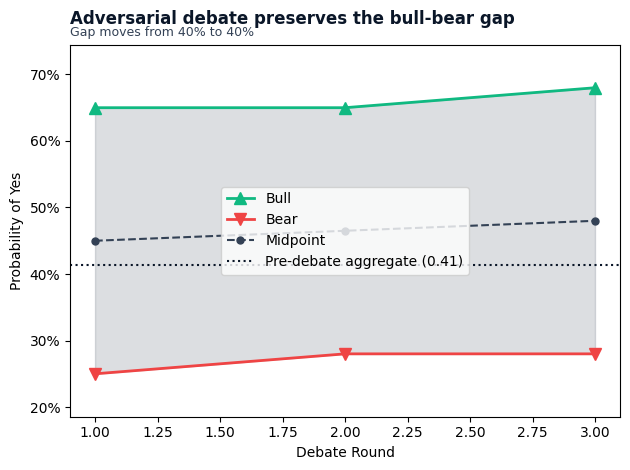

In [16]:
fig, ax = plt.subplots()
ax.plot(
    rounds_x, bull_probs, "^-", color=COLORS["positive"], markersize=8, label="Bull", linewidth=2
)
ax.plot(
    rounds_x, bear_probs, "v-", color=COLORS["negative"], markersize=8, label="Bear", linewidth=2
)
ax.plot(rounds_x, midpoints, "o--", color=COLORS["neutral"], markersize=5, label="Midpoint")
ax.fill_between(rounds_x, bull_probs, bear_probs, alpha=0.15, color=COLORS["blue_light"])
ax.axhline(agg_p, color=COLORS["blue"], linestyle=":", label=f"Pre-debate aggregate ({agg_p:.2f})")
ax.set_xlabel("Debate Round")
ax.set_ylabel("Probability of Yes")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
add_message_title(
    ax,
    f"Adversarial debate {direction} the bull-bear gap",
    subtitle=f"Gap moves from {gaps[0]:.0%} to {gaps[-1]:.0%}",
)
ax.legend(loc="best")
y_min = min(bear_probs + bull_probs + [agg_p])
y_max = max(bear_probs + bull_probs + [agg_p])
pad = max(0.05, (y_max - y_min) * 0.15)
ax.set_ylim(max(0.0, y_min - pad), min(1.0, y_max + pad))
fig.tight_layout()
fig.show()
plt.show()

**Interpretation**: The figure shows whether the bull-bear gap narrows,
widens, or stays flat across rounds. A narrowing gap is productive debate: the
final midpoint reflects adversarial stress-testing that simple averaging
misses. A flat or widening gap means the two sides hold genuinely
irreconcilable views and the midpoint carries wider uncertainty rather than a
consensus update. The captured run on this question keeps a wide gap across all
three rounds, so the midpoint should be read as an uncertainty signal, not a
sharpened forecast.

## Post-Debate Probability

The debate midpoint adjusts the aggregate probability. We blend the pre-debate
aggregate with the debate midpoint (70/30 weighting).

In [17]:
pre_debate = agg_p
debate_midpoint = (result.bull_final_probability + result.bear_final_probability) / 2

blended = 0.7 * pre_debate + 0.3 * debate_midpoint

print(f"Pre-debate aggregate:  {pre_debate:.2f}")
print(f"Debate midpoint:       {debate_midpoint:.2f}")
print(f"Blended (70/30):       {blended:.2f}")
print(f"Shift from debate:     {blended - pre_debate:+.2f}")

if result.consensus_reached:
    print("\nDebate reached consensus — high confidence in the blended estimate.")
else:
    print("\nNo consensus — wider uncertainty; consider reducing confidence.")

Pre-debate aggregate:  0.41
Debate midpoint:       0.48
Blended (70/30):       0.43
Shift from debate:     +0.02

No consensus — wider uncertainty; consider reducing confidence.


## When Does Debate Add Value?

Decision rule used by the cell below: run debate when pre-debate agent
disagreement exceeds 15 percentage points and the resulting blend shifts the
aggregate by more than 3 percentage points. Below those thresholds, debate
spends tokens without changing the forecast.

In [18]:
agent_range = max(probs) - min(probs)
debate_shift = abs(blended - pre_debate)

print(f"Agent disagreement: {agent_range:.2f} ({agent_range:.0%})")
print(f"Debate probability shift: {debate_shift:.2f} ({debate_shift:.0%})")

if agent_range > 0.15 and debate_shift > 0.03:
    print("→ Debate was productive (high disagreement, meaningful shift)")
elif agent_range < 0.05:
    print("→ Debate was low-value (agents already agreed)")
else:
    print("→ Debate had marginal impact")

Agent disagreement: 0.23 (23%)
Debate probability shift: 0.02 (2%)
→ Debate had marginal impact


## Persisting the Full Run Trace

The same auditing discipline as NB06, now covering both stages. `RunTrace`
bundles the question, the research-agent artifacts, the complete debate
transcript, and the raw model conversation for every research and debate call
— captured by the per-agent and debate `TracingLLMClient`s — into one JSON
record under `forecast_traces/`. Reload it to replay exactly what each
debater was shown and how it responded, round by round.

In [19]:
if RUN_LIVE:
    llm_calls = merge_calls(*agent_tracers, debate_tracer)
    run = RunTrace.capture(
        notebook="07_adversarial_debate",
        provider=provider_name,
        question=question,
        params={
            "n_agents": N_AGENTS,
            "debate_rounds": DEBATE_ROUNDS,
            "consensus_threshold": CONSENSUS_THRESHOLD,
            "max_steps": MAX_STEPS,
        },
        agents=artifacts,
        aggregation=aggregate,
        debate=result,
        final_probability=blended,
        notes="Bull/bear debate on the pinned contested question.",
        llm_calls=llm_calls,
    )
    trace_path = run.save()
    print(
        f"Saved {len(run.llm_calls)} model calls "
        f"({run.total_tokens():,} tokens) → {trace_path.relative_to(trace_path.parents[1])}"
    )
else:
    # Replay: report the pinned trace we loaded rather than writing a new file.
    llm_calls = pinned_run.call_log()
    run = pinned_run
    trace_path = TRACES_DIR / PINNED_TRACE
    print(
        f"Replayed {len(run.llm_calls)} model calls "
        f"({run.total_tokens():,} tokens) from {trace_path.name}"
    )

Replayed 20 model calls (93,189 tokens) from 07_adversarial_debate_20260609T141631Z_cf1ad76cf379.json


## Replaying the Debate Calls

The raw audit view for the debate: every bull and bear prompt — including the
opposing side's previous argument that gets fed back in each round — next to
the untruncated JSON each debater returned. The transcript and trajectory
figure above are both derived from exactly these responses.

In [20]:
debate_calls = [c for c in llm_calls if c.label == "debate"]
print(replay_llm_calls(debate_calls, content_chars=700))

  CALL #14 [debate]  ·  claude-sonnet-4-20250514  ·  json_mode=True  ·  tokens in/out=428/330
------------------------------------------------------------------------------
  ▸ USER:
      You are the BULL debater in a structured forecasting debate.
      Your role is to argue for a HIGHER probability of YES for the question
      below.
      You must present the strongest possible case for YES, backed by
      evidence.
      QUESTION:
      Will the Federal Reserve hike rates in 2026?
      AGENT SUMMARIES:
      Agent: agent_0
      Probability (p_yes): 0.35
      Confidence: 0.30
      Rationale: Current evidence strongly suggests rate cuts rather than
      hikes in 2026. The Fed's December 2025 projections forecast only 1 rate
      cut in 2026, bringing rates to 3.25-3.5%. Core PCE inflation is project
      ---
      Agent: agent_1
      Probability (p_yes): 0.58
      Confidence: 0.16
      Rationale: Based on current economic data, the Fed faces persistent
      inflationa…


## Key Takeaways

1. **Trajectory shape is the signal**: A narrowing bull-bear gap shows
   information being incorporated; a flat or widening gap means the debate
   has not surfaced new evidence and is noise. The chapter trace preserves
   the 40% endpoint gap after a transient narrowing to 37%: the bear moves
   from 25% to 28% in round two, and the bull moves from 65% to 68% in round
   three. The positions change, but the wide disagreement survives.
2. **Midpoint ≠ average**: The debate midpoint captures adversarial stress-testing
   that simple agent averaging misses
3. **Consensus gating**: Early termination when the gap closes below threshold
   saves token budget without losing information
4. **Debate adds most value when agents disagree** — if they're already
   aligned, debate is a waste of tokens

**Next**: [`08_forecasting_pipeline`](08_forecasting_pipeline.ipynb) — wire everything together into the full
agent → aggregation → debate → supervisor pipeline.

**Book**: Section 24.7 discusses the debate pattern in the context of Bridgewater's
AIA system and prediction market design.